In [1]:
%load_ext autoreload
%autoreload 2
from typing import Literal
import torch
import torch.nn as nn   
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import sys
from csbdeep.utils import normalize
from scipy.ndimage import uniform_filter1d
from freq2clean import Freq2Clean
import json
import tifffile as tiff
import seaborn as sns

sys.path.append("..")
from src import *

/home/vmorelli-iit.local/Projects/freq2clean/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cupy Available= 1


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
SELECTED_TRAINING = "20251118-1205-synthetic_deepcad_15" # "20251118-1205-synthetic_deepcad_15"
USE_VARIANT_085 = False
DENOISER_VARIANT: str | None = "_150"

In [3]:
# 10s
cfg = json.load(open(f"trainings/{SELECTED_TRAINING}/cfg.json"))
variant = DENOISER_VARIANT or cfg["denoiser_variant"]
deepcad = Recording(
    f"dataset/{cfg["dataset_name"]}/{cfg["denoiser_name"]}{variant}.tif",
    max_frames=None,
)
f2c_grid = Recording(
    f"results/{cfg["dataset_name"]}/{cfg["denoiser_name"]}{variant}/grid.tiff",
    max_frames=None,
)
f2c_net = Recording(
    f"results/{cfg["dataset_name"]}/{cfg["denoiser_name"]}{variant}/{SELECTED_TRAINING}{'_0.85' if USE_VARIANT_085 else ''}.tiff",
    max_frames=None,
)
gt = Recording(
    f"dataset/{cfg["dataset_name"]}/gt.tif",
    max_frames=None,
)

In [4]:
deepcad = deepcad.normalized
gt = gt.normalized

In [5]:
f2c_grid = f2c_grid.np
f2c_net = f2c_net.np

In [6]:
f2c_grid = np.clip(f2c_grid, 0, 1)
f2c_net = np.clip(f2c_net, 0, 1)

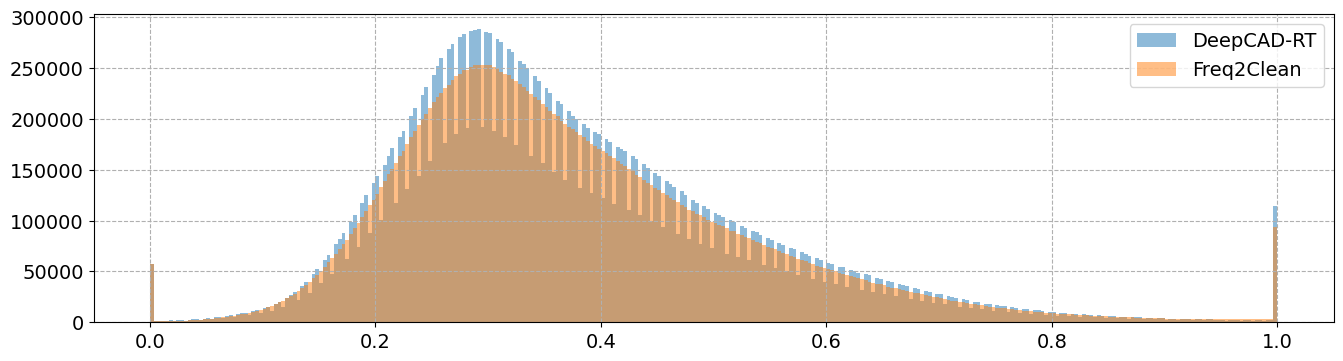

In [7]:
ax = pd.Series(deepcad.flatten()[::64]).hist(bins=300, alpha=0.5, figsize=(16, 4), label="DeepCAD-RT")
pd.Series(f2c_net.flatten()[::64]).hist(bins=300, alpha=0.5, ax=ax, label="Freq2Clean")
plt.legend();

The distribution is aligned, no need to *normalize* `f2c_grid` and `f2c_net`.

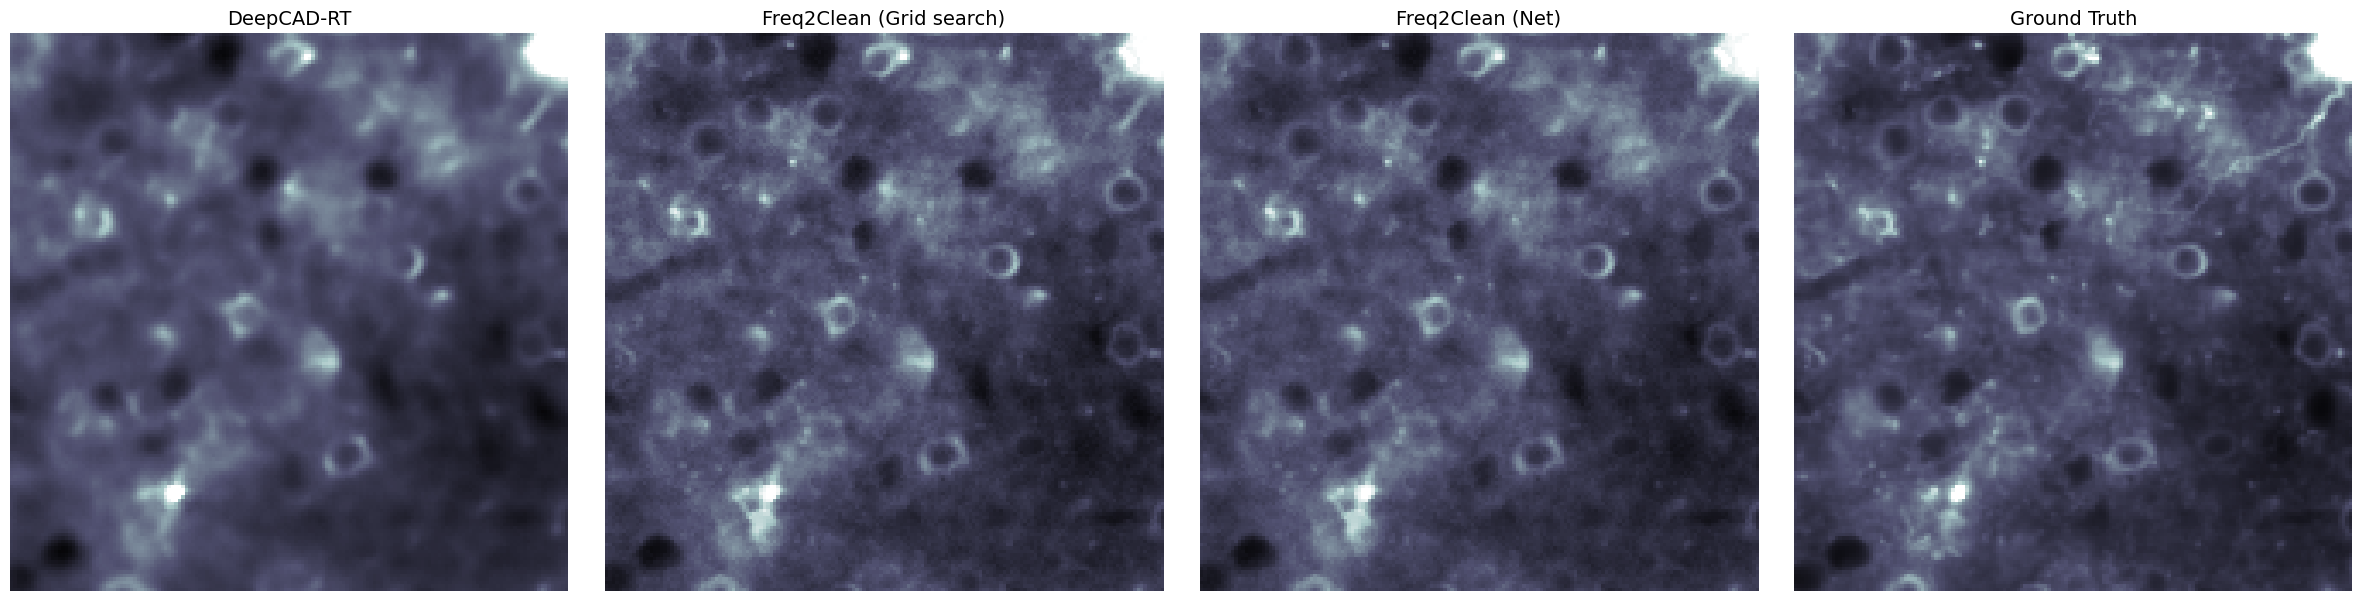

In [8]:
frame = random.randrange(gt.shape[0])
imshow(
    {
        "DeepCAD-RT": deepcad[frame],
        "Freq2Clean (Grid search)": f2c_grid[frame],
        "Freq2Clean (Net)": f2c_net[frame],
        "Ground Truth": gt[frame],
    },
    size=6,
    cmap="bone",
    zoom=3,
    vrange=(0,1)
)

In [9]:
# 5s
psnr_deepcad = psnr3d(gt, deepcad, data_range=1)
psnr_grid = psnr3d(gt, f2c_grid, data_range=1)
psnr_net = psnr3d(gt, f2c_net, data_range=1)

In [10]:
# 20s
ssim_deepcad = ssim3d(gt, deepcad, step=6)
ssim_grid = ssim3d(gt, f2c_grid, step=6)
ssim_net = ssim3d(gt, f2c_net, step=6)

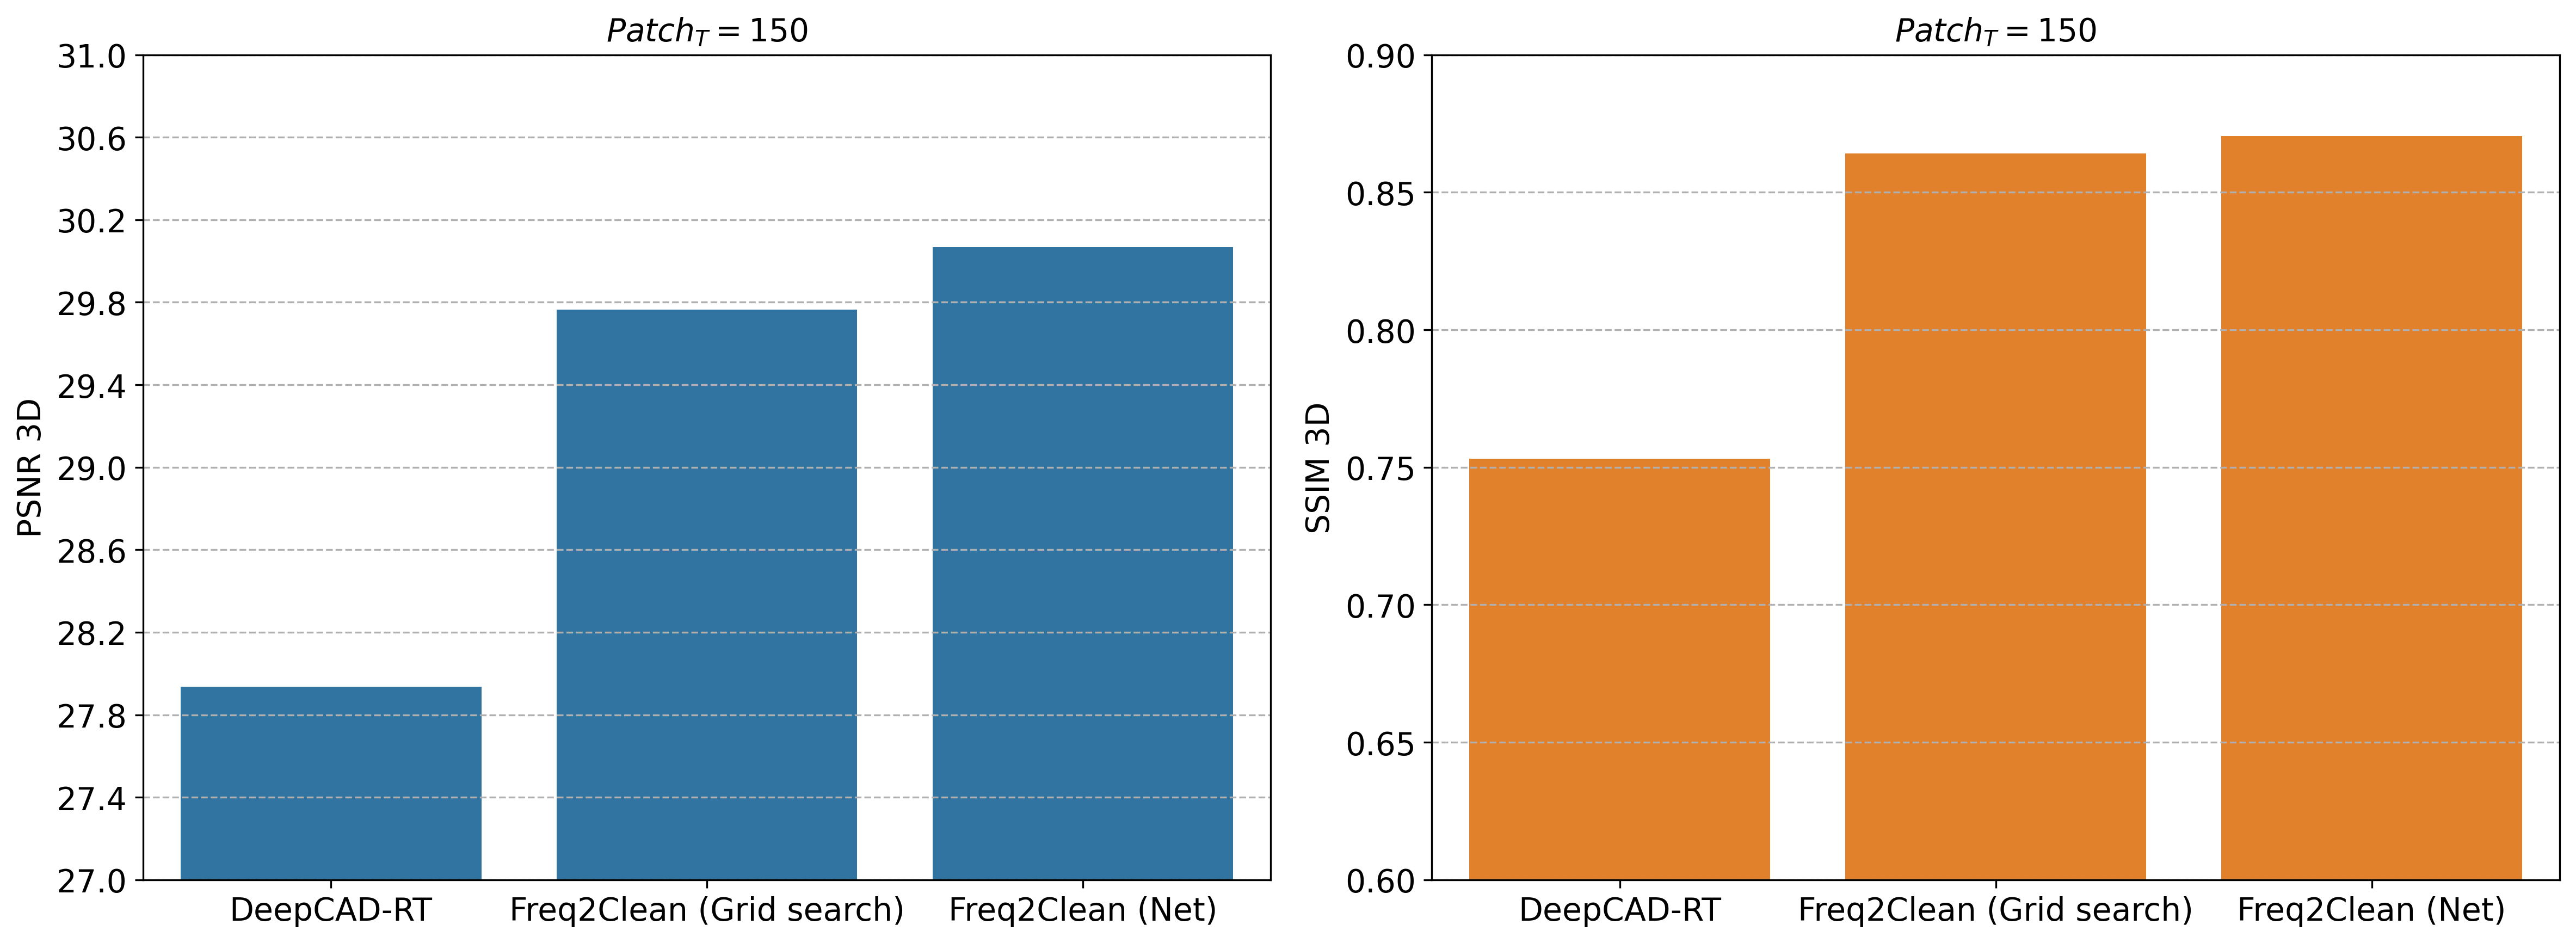

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
barchart(
    {
        "DeepCAD-RT": psnr_deepcad,
        "Freq2Clean (Grid search)": psnr_grid,
        "Freq2Clean (Net)": psnr_net,
    },
    bounds=(27, 31),
    yaxis="PSNR 3D",
    ysteps=10,
    color="tab:blue",
    title=f"$Patch_T={variant[1:]}$",
    ax=axs[0],
)
barchart(
    {
        "DeepCAD-RT": ssim_deepcad,
        "Freq2Clean (Grid search)": ssim_grid,
        "Freq2Clean (Net)": ssim_net,
    },
    bounds=(0.6, 0.9),
    yaxis="SSIM 3D",
    ysteps=6,
    color="tab:orange",
    title=f"$Patch_T={variant[1:]}$",
    ax=axs[1],
)

The Freq2Clean(net) generalizes *quite* good. When I use the variant `150` on the dataset `15` and viceversa, it performs *slightly* worse than the version trainined for the same dataset.